# EDA

In [3]:
pip install numpy pandas matplotlib librosa scikit-learn tensorflow keras soundfile joblib jupyter

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached tensorflow-2.21.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached soundfile-0.13.1-py2.py3-none-macosx_11_0_arm64.whl.metadata (16 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached numba-0.64.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (2.9 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.0.0-cp312-abi3-macosx_11_0_arm64.whl.metadata (5.6 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached msgpack-1.1.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.1 kB)
  Using cached standard_aifc-3.13.0-py3-none-any.whl.metadata (969 bytes)
  Using cached standard_sunau-3.13.0-py3-none-any.whl.metadata (914 bytes)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata 

In [9]:
import sys
!{sys.executable} -m pip install scikeras


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [12]:
# IMPORT NECESSARY LIBRARIES
import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd  # To play sound in the notebook
import os # interface with underlying OS that python is running on
import sys
import warnings
# ignore warnings 
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras.layers import Input, Flatten, Dropout, Activation, BatchNormalization, Dense
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report

## Male Neutral

In [19]:
# LOAD IN FILE
x, sr = librosa.load('/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_01/03-01-01-01-01-01-01.wav')

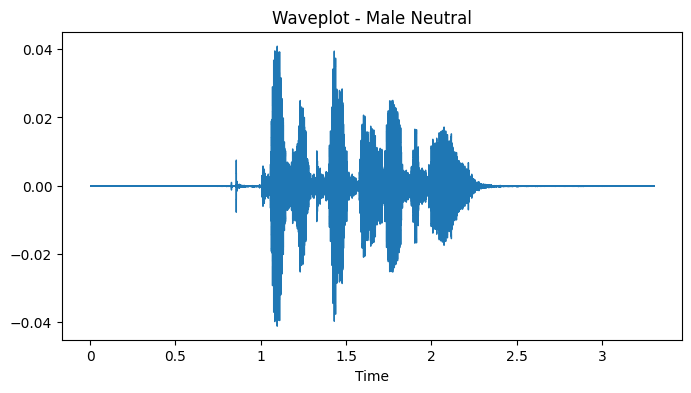

In [21]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(8, 4))
librosa.display.waveshow(x, sr=sr)
plt.title('Waveplot - Male Neutral')
plt.savefig('Waveplot_MaleNeutral.png')
plt.show()

In [23]:
import soundfile as sf
from IPython.display import Audio

# Save audio file
sf.write('MaleNeutral.wav', x, sr)

# Play audio
Audio(data=x, rate=sr)

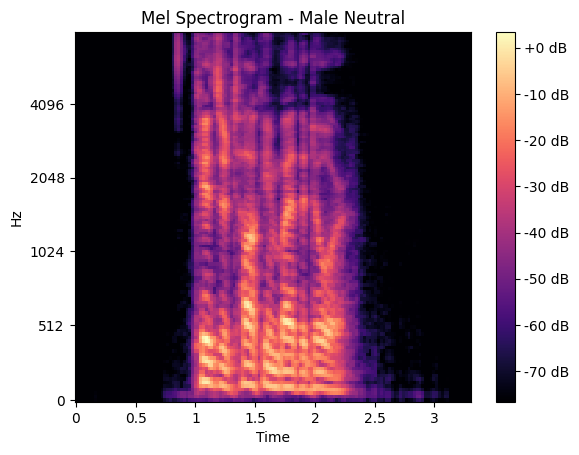

In [24]:
# CREATE LOG MEL SPECTROGRAM
spectrogram = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=128,fmax=8000) 
spectrogram = librosa.power_to_db(spectrogram)

librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - Male Neutral')
plt.savefig('MelSpec_MaleNeutral.png')
plt.colorbar(format='%+2.0f dB');

## Female Calm

In [25]:
# LOAD IN FILE
x, sr = librosa.load('/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_02/03-01-01-01-01-01-02.wav')

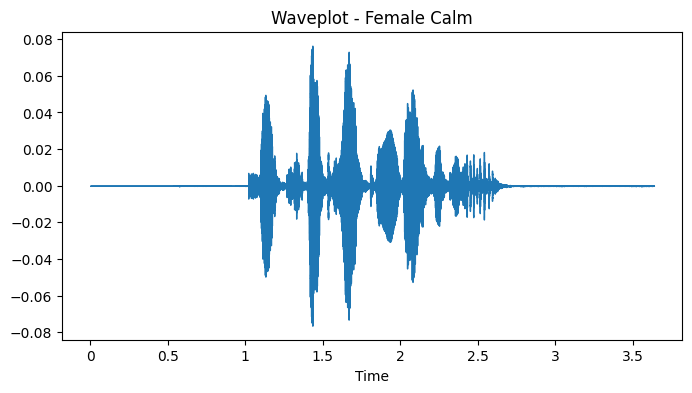

In [28]:
import matplotlib.pyplot as plt
import librosa.display
plt.figure(figsize=(8, 4))
librosa.display.waveshow(x, sr=sr)
plt.title('Waveplot - Female Calm')
plt.savefig('Waveplot_FemaleCalm.png')
plt.show()

In [31]:
import soundfile as sf
from IPython.display import Audio

# Save audio file
sf.write('FemaleCalm.wav', x, sr)

# Play audio
Audio(data=x, rate=sr)

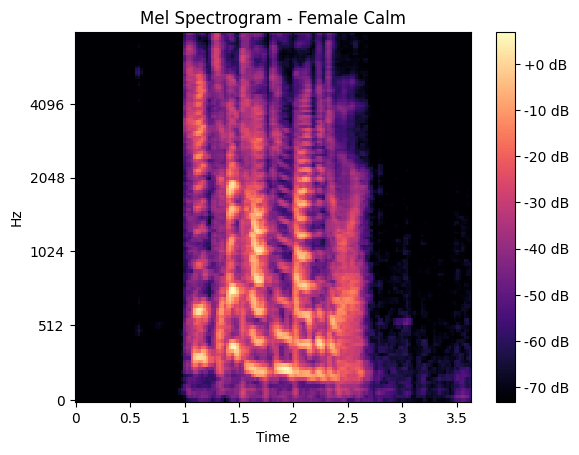

In [32]:
# CREATE LOG MEL SPECTROGRAM
spectrogram = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=128,fmax=8000) 
spectrogram = librosa.power_to_db(spectrogram)

librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - Female Calm')
plt.savefig('MelSpec_FemaleCalm.png')
plt.colorbar(format='%+2.0f dB');

## Male Happy

In [33]:
# LOAD FILE
x, sr = librosa.load('/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_03/03-01-01-01-01-01-03.wav')

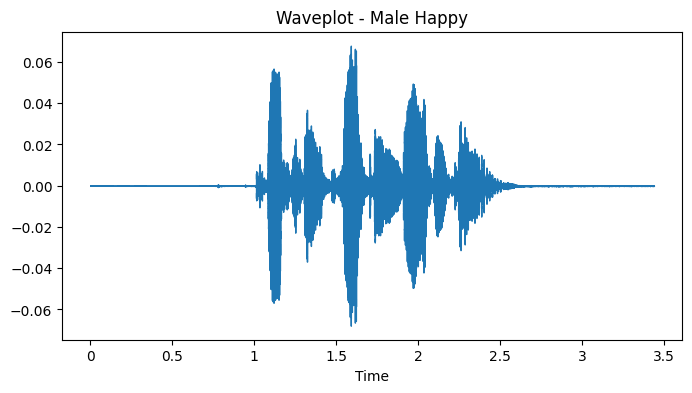

In [34]:
# DISPLAY WAVEPLOT
import matplotlib.pyplot as plt
import librosa.display
plt.figure(figsize=(8, 4))
librosa.display.waveshow(x, sr=sr)
plt.title('Waveplot - Male Happy')
plt.savefig('Waveplot_MaleHappy.png')

In [36]:
import soundfile as sf
from IPython.display import Audio

# Save audio file
sf.write('MaleHappy.wav', x, sr)

# Play audio
Audio(data=x, rate=sr)

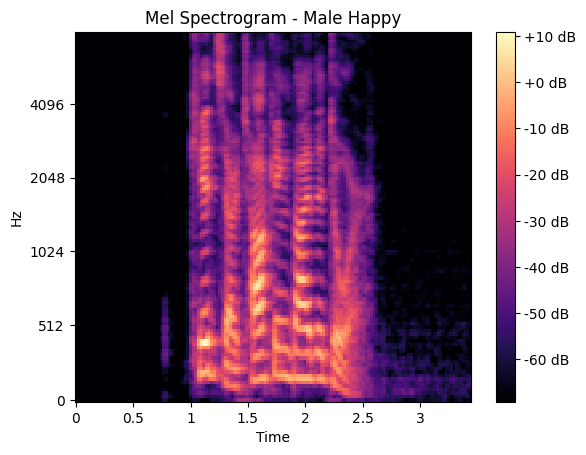

In [37]:
# CREATE LOG MEL SPECTROGRAM
x = librosa.feature.melspectrogram(y=x, sr=sr,n_mels=128,fmax=8000) 
x = librosa.power_to_db(x)

librosa.display.specshow(x, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - Male Happy')
plt.savefig('MelSpec_MaleHappy.png')
plt.colorbar(format='%+2.0f dB');

## Female Sad

In [3]:
# LOAD FILE
x, sr = librosa.load('/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_04/03-01-01-01-01-01-04.wav')


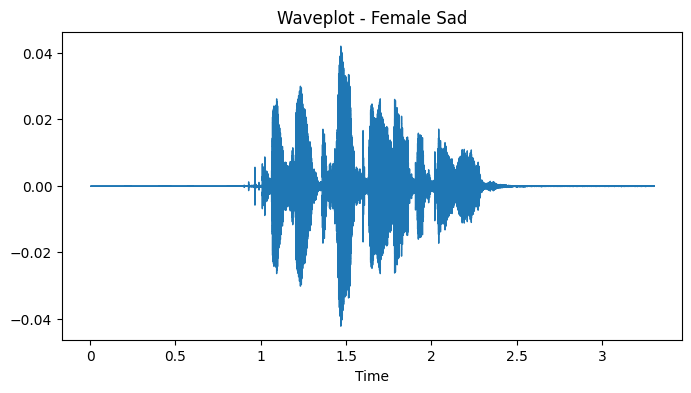

In [4]:
# DISPLAY WAVEPLOT
import matplotlib.pyplot as plt
import librosa.display
plt.figure(figsize=(8, 4))
librosa.display.waveshow(x, sr=sr)
plt.title('Waveplot - Female Sad')
plt.savefig('Waveplot_FemaleSad.png')

In [5]:
# PLAY AUDIO FILE

import soundfile as sf
from IPython.display import Audio

# Save audio file
sf.write('FemaleSad.wav', x, sr)

# Play audio
Audio(data=x, rate=sr)

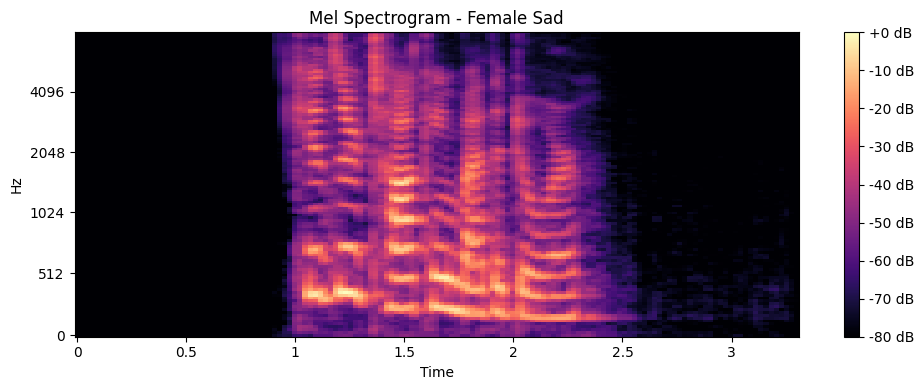

In [6]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Generate mel spectrogram (DO NOT overwrite x)
mel_spec = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=128, fmax=8000)

# Step 2: Convert to dB
mel_db = librosa.power_to_db(mel_spec, ref=np.max)

# Step 3: Plot
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', fmax=8000)

plt.title('Mel Spectrogram - Female Sad')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.savefig('MelSpec_FemaleSad.png')
plt.show()

## Male Angry

In [7]:
# LOAD FILE
x, sr = librosa.load('/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_05/03-01-01-01-01-01-05.wav')


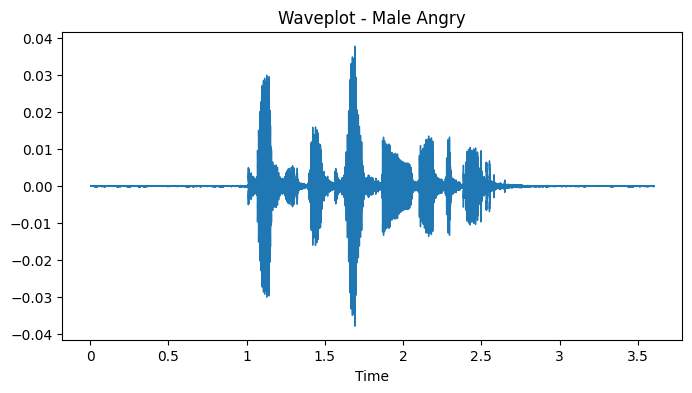

In [10]:
# DISPLAY WAVEPLOT
import matplotlib.pyplot as plt
import librosa.display
plt.figure(figsize=(8, 4))
librosa.display.waveshow(x, sr=sr)

plt.title('Waveplot - Male Angry')
plt.savefig('Waveplot_MaleAngry.png')

In [11]:
# PLAY AUDIO FILE
import soundfile as sf
from IPython.display import Audio

# Save audio file
sf.write('MaleAngry.wav', x, sr)

# Play audio
Audio(data=x, rate=sr)

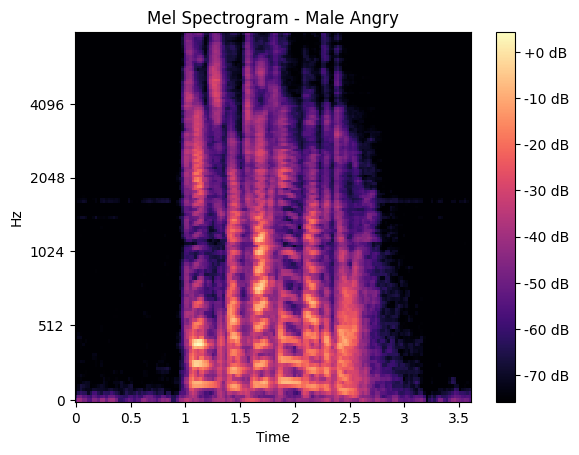

In [12]:
# DISPLAY LOG MEL SPECTROGRAM
x = librosa.feature.melspectrogram(y=x, sr=sr,n_mels=128,fmax=8000) 
y = librosa.power_to_db(x)

librosa.display.specshow(y, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - Male Angry');
plt.savefig('MelSpec_MaleAngry.png')
plt.colorbar(format='%+2.0f dB');

## Female Fearful

In [42]:
# LOAD FILE
x, sr = librosa.load('/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_06/03-01-01-01-01-01-06.wav')

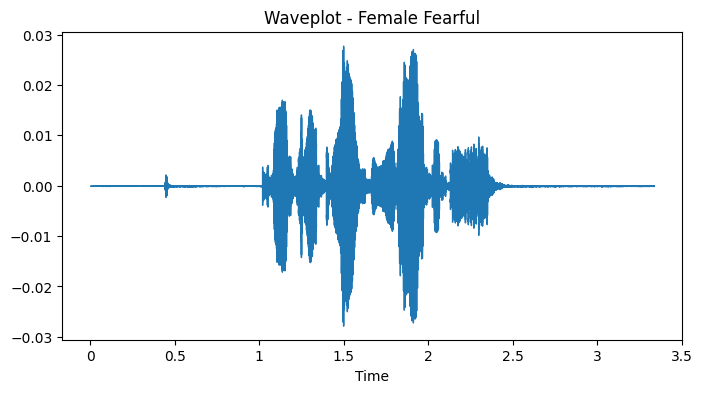

In [44]:
# DISPLAY WAVEPLOT
import matplotlib.pyplot as plt
import librosa.display
plt.figure(figsize=(8, 4))
librosa.display.waveshow(x, sr=sr)
plt.title('Waveplot - Female Fearful')
plt.savefig('Waveplot_FemaleFearful.png')


In [45]:
# PLAY AUDIO FILE

import soundfile as sf
from IPython.display import Audio

# Save audio file
sf.write('FemaleFearful.wav', x, sr)

# Play audio
Audio(data=x, rate=sr)

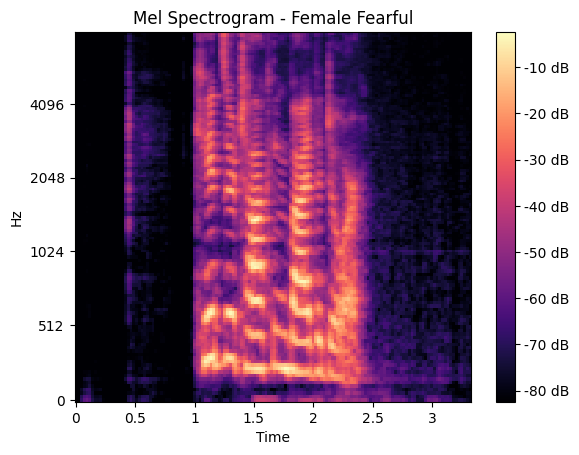

In [46]:
# DISPLAY LOG MEL SPECTROGRAM
x = librosa.feature.melspectrogram(y=x, sr=sr,n_mels=128,fmax=8000) 
y = librosa.power_to_db(x)

librosa.display.specshow(y, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - Female Fearful')
plt.savefig('MelSpec_FemaleFearful.png')
plt.colorbar(format='%+2.0f dB');

## Male Disgust

In [13]:
# LOAD FILE
x, sr = librosa.load('/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_07/03-01-01-01-01-01-07.wav')



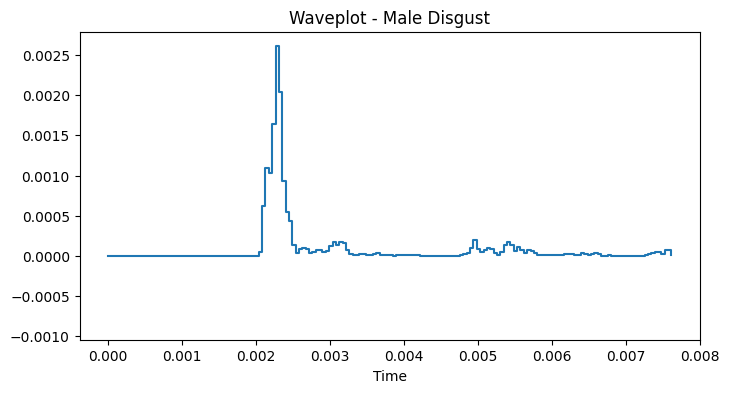

In [17]:
# DISPLAY WAVEPLOT
import matplotlib.pyplot as plt
import librosa.display
plt.figure(figsize=(8, 4))
librosa.display.waveshow(x, sr=sr)
plt.title('Waveplot - Male Disgust')
plt.savefig('Waveplot_MaleDisgust.png')


In [14]:
# PLAY AUDIO FILE

import soundfile as sf
from IPython.display import Audio

# Save audio file
sf.write('MaleDisgust.wav', x, sr)

# Play audio
Audio(data=x, rate=sr)

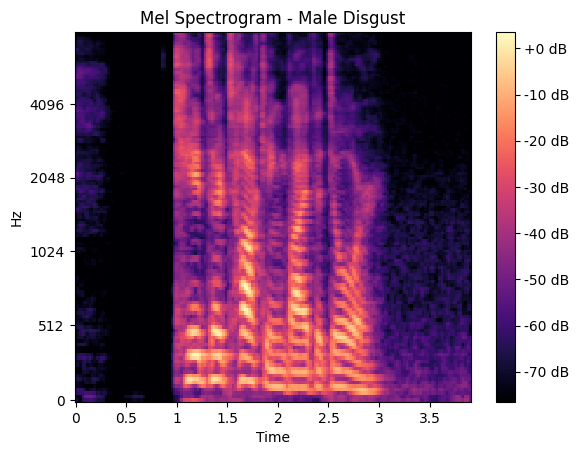

In [15]:
# DISPLAY LOG MEL SPECTROGRAM
x = librosa.feature.melspectrogram(y=x, sr=sr,n_mels=128,fmax=8000) 
y = librosa.power_to_db(x)

librosa.display.specshow(y, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - Male Disgust')
plt.savefig('MelSpec_MaleDisgust.png')
plt.colorbar(format='%+2.0f dB');

## Female Surprised

In [25]:
# LOAD FILE
x, sr = librosa.load('/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_08/03-01-01-01-01-01-08.wav')

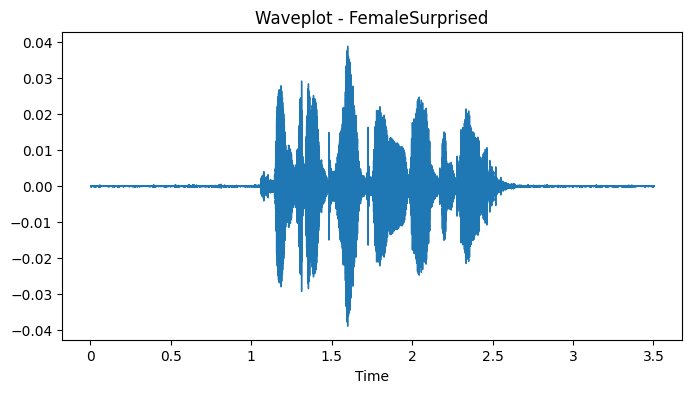

In [26]:
# DISPLAY WAVEPLOT
import matplotlib.pyplot as plt
import librosa.display
plt.figure(figsize=(8, 4))
librosa.display.waveshow(x, sr=sr)
plt.title('Waveplot - FemaleSurprised')
plt.savefig('Waveplot_FemaleSurprised.png')


In [27]:
# PLAY AUDIO FILE

import soundfile as sf
from IPython.display import Audio

# Save audio file
sf.write('FemaleSurprised.wav', x, sr)

# Play audio
Audio(data=x, rate=sr)

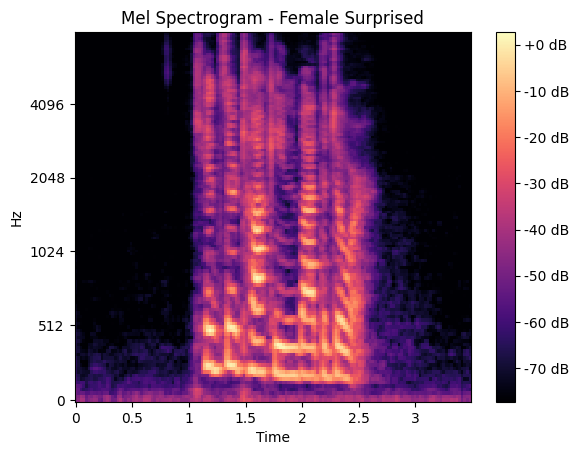

In [28]:
# DISPLAY LOG MEL SPECTROGRAM
x = librosa.feature.melspectrogram(y=x, sr=sr,n_mels=128,fmax=8000) 
y = librosa.power_to_db(x)

librosa.display.specshow(y, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - Female Surprised')
plt.savefig('MelSpec_FemaleSurprised.png')
plt.colorbar(format='%+2.0f dB');

# Data Preprocessing

## Labeling Audio Files

In [31]:
# CREATE DIRECTORY OF AUDIO FILES 
import os
audio = "/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/"
actor_folders = os.listdir(audio) #list files in audio directory
actor_folders.sort() 
actor_folders[0:5]

['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']

In [32]:
# CREATE FUNCTION TO EXTRACT EMOTION NUMBER, ACTOR AND GENDER LABEL
emotion = []
gender = []
actor = []
file_path = []
for i in actor_folders:
    filename = os.listdir(audio + i) #iterate over Actor folders
    for f in filename: # go through files in Actor folder
        part = f.split('.')[0].split('-')
        emotion.append(int(part[2]))
        actor.append(int(part[6]))
        bg = int(part[6])
        if bg%2 == 0:
            bg = "female"
        else:
            bg = "male"
        gender.append(bg)
        file_path.append(audio + i + '/' + f)

In [36]:
# PUT EXTRACTED LABELS WITH FILEPATH INTO DATAFRAME
import pandas as pd
audio_df = pd.DataFrame(emotion)
audio_df = audio_df.replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'})
audio_df = pd.concat([pd.DataFrame(gender),audio_df,pd.DataFrame(actor)],axis=1)
audio_df.columns = ['gender','emotion','actor']
audio_df = pd.concat([audio_df,pd.DataFrame(file_path, columns = ['path'])],axis=1)
audio_df

,gender,emotion,actor,path
0,male,surprise,1,/Users/dhrithimv/Downloads/archive/audio_speec...
1,male,surprise,1,/Users/dhrithimv/Downloads/archive/audio_speec...
2,male,angry,1,/Users/dhrithimv/Downloads/archive/audio_speec...
3,male,fear,1,/Users/dhrithimv/Downloads/archive/audio_speec...
4,male,fear,1,/Users/dhrithimv/Downloads/archive/audio_speec...
...,...,...,...,...
1435,female,fear,24,/Users/dhrithimv/Downloads/archive/audio_speec...
1436,female,fear,24,/Users/dhrithimv/Downloads/archive/audio_speec...
1437,female,angry,24,/Users/dhrithimv/Downloads/archive/audio_speec...
1438,female,surprise,24,/Users/dhrithimv/Downloads/archive/audio_speec...


In [38]:
# ENSURE GENDER,EMOTION, AND ACTOR COLUMN VALUES ARE CORRECT
import pandas as pd

pd.set_option('display.max_colwidth', None)

audio_df.sample(10)

,gender,emotion,actor,path
79,female,calm,2,/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_02/03-01-02-01-01-02-02.wav
1022,female,calm,18,/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_18/03-01-02-02-02-01-18.wav
1324,male,angry,23,/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_23/03-01-05-02-02-01-23.wav
851,male,happy,15,/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_15/03-01-03-01-01-02-15.wav
387,male,calm,7,/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_07/03-01-02-02-02-02-07.wav
434,female,happy,8,/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_08/03-01-03-02-01-02-08.wav
645,male,happy,11,/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_11/03-01-03-02-01-02-11.wav
337,female,disgust,6,/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_06/03-01-07-01-01-02-06.wav
1005,male,fear,17,/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_17/03-01-06-01-01-02-17.wav
186,female,fear,4,/Users/dhrithimv/Downloads/archive/audio_speech_actors_01-24/Actor_04/03-01-06-01-02-02-04.wav


<Axes: xlabel='emotion'>

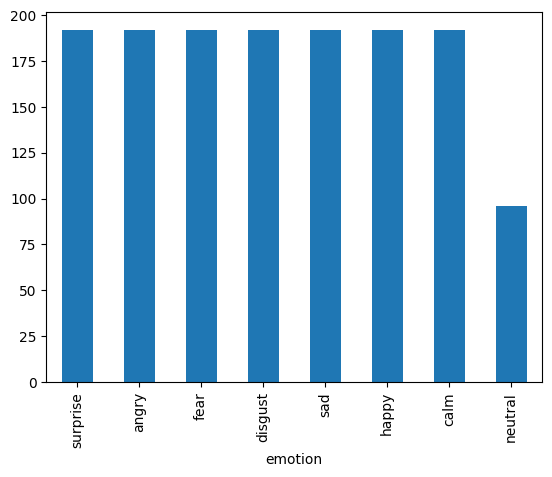

In [39]:
# LOOK AT DISTRIBUTION OF CLASSES
audio_df.emotion.value_counts().plot(kind='bar')

In [40]:
# EXPORT TO CSV
audio_df.to_csv('Uploads/audio.csv')

## Feature Extraction

In [42]:
df = pd.DataFrame(columns=['mel_spectrogram'])

counter = 0

for index, path in enumerate(audio_df.path):
    X, sample_rate = librosa.load(path, duration=3, offset=0.5)

    spectrogram = librosa.feature.melspectrogram(
        y=X, sr=sample_rate, n_mels=128, fmax=8000
    )

    db_spec = librosa.power_to_db(spectrogram, ref=np.max)

    log_spectrogram = np.mean(db_spec, axis=1)  # FIXED

    df.loc[counter] = [log_spectrogram]
    counter += 1

print(len(df))
df.head()

1440


,mel_spectrogram
0,"[-68.67651, -65.54892, -64.71095, -61.403404, -51.895416, -45.08883, -43.84782, -48.469566, -53.793915, -54.42558, -51.624863, -48.914394, -48.43041, -48.88065, -50.343487, -51.389687, -50.88737, -49.858826, -48.90005, -48.068764, -48.922844, -49.84991, -50.68052, -52.35389, -52.41297, -53.299152, -54.1352, -53.82282, -52.7993, -54.40183, -55.26791, -54.638092, -55.461906, -56.77648, -57.89411, -59.675274, -59.039955, -58.877567, -58.492214, -59.070034, -59.540436, -59.425648, -59.0386, -58.454018, -56.54648, -57.99197, -57.969246, -56.171867, -55.8927, -57.02424, -57.729794, -58.786896, -57.922535, -56.66754, -55.28312, -55.26612, -56.117134, -57.29045, -56.71434, -56.233406, -55.767384, -55.996906, -56.857056, -57.038906, -57.30223, -57.727894, -58.61961, -58.86995, -59.40855, -60.074406, -60.69782, -60.507282, -59.46343, -60.520317, -60.47433, -59.58431, -58.713066, -58.275043, -58.884632, -58.285393, -58.187855, -59.59139, -60.179928, -60.478806, -61.27425, -60.819435, -61.028255, -59.906746, -60.339115, -59.733715, -59.24124, -58.625004, -58.3299, -57.26051, -57.18489, -57.33511, -58.592266, -60.778427, -62.51206, -63.077255, ...]"
1,"[-72.04303, -68.51214, -63.67634, -57.140167, -52.598557, -51.195007, -52.412464, -52.765053, -51.47235, -52.920834, -54.615894, -55.002384, -54.63629, -54.10773, -54.12809, -54.02095, -52.628628, -53.66941, -55.12014, -55.091064, -55.151684, -54.871185, -54.424496, -55.39114, -56.63058, -57.07391, -57.79385, -59.01994, -58.82991, -60.245667, -60.40653, -59.414337, -59.969257, -60.95465, -62.28115, -63.551525, -63.618748, -63.898136, -63.399662, -63.466873, -62.20339, -61.99943, -62.999756, -63.815014, -62.61461, -62.565548, -62.105007, -60.713146, -61.109425, -63.227623, -63.93394, -63.049026, -61.69062, -61.742306, -60.93973, -60.82139, -62.35106, -62.673985, -61.78656, -61.474926, -60.525124, -61.755558, -62.537746, -62.57255, -64.09631, -64.82559, -64.84077, -63.775646, -63.686607, -64.20713, -64.56737, -64.48782, -63.93885, -64.74986, -65.30419, -64.36297, -63.78992, -63.281864, -63.661945, -62.75447, -62.204838, -64.15195, -65.30171, -66.32964, -65.91567, -66.89292, -66.82345, -66.54044, -66.69246, -66.35288, -65.95371, -65.251724, -65.31751, -64.76557, -64.925354, -65.780136, -66.75177, -68.22666, -69.93688, -70.85292, ...]"
2,"[-71.17251, -67.048065, -63.029213, -58.322033, -54.817554, -51.20235, -50.546455, -52.61564, -52.839973, -52.361816, -52.816658, -53.613155, -53.892597, -53.206707, -53.713898, -53.701675, -52.166607, -51.983692, -52.21709, -52.120155, -53.057457, -54.784004, -54.58109, -55.355003, -56.0942, -55.950993, -56.130543, -57.898113, -58.026546, -60.373775, -60.287643, -59.16597, -59.964718, -61.1091, -61.46729, -62.509396, -61.34688, -61.447975, -61.45977, -61.71767, -61.31019, -61.685886, -62.118866, -62.29662, -61.084488, -61.22887, -60.73647, -59.69783, -60.59643, -61.28421, -61.172028, -60.770008, -59.83167, -59.85692, -60.913036, -60.711853, -60.273083, -60.893238, -61.52398, -61.27023, -60.240753, -60.844467, -61.637817, -60.906075, -61.215694, -62.635082, -63.180485, -63.29997, -63.485786, -63.71066, -63.967384, -64.34285, -64.01743, -63.907692, -63.871876, -63.328823, -62.392315, -61.694897, -62.09057, -61.093887, -60.943726, -61.672405, -62.503704, -63.777786, -64.09546, -64.25787, -65.065, -64.44523, -63.731445, -63.432255, -62.53528, -62.15187, -61.83419, -61.508675, -61.13885, -61.546513, -62.53408, -63.821167, -65.84237, -66.38468, ...]"
3,"[-58.323524, -55.449043, -54.508347, -46.013317, -38.8308, -39.720608, -48.683956, -54.23719, -49.493504, -43.572712, -41.154892, -43.935562, -50.376564, -49.402306, -44.6798, -41.350677, -41.67872, -46.37988, -48.203323, -45.341053, -43.02231, -44.34894, -46.505108, -50.511787, -50.76281, -48.268078, -48.427353, -50.28663, -51.747467, -54.39831, -54.071342, -51.385864, -52.31425, -56.000595, -57.564957, -58.75205, -56.358875, -56.11618, -56.170834, -57.347973, -56.71359, -56.75711, -57.947365, -5

In [43]:
# TURN ARRAY INTO LIST AND JOIN WITH AUDIO_DF TO GET CORRESPONDING EMOTION LABELS
df_combined = pd.concat([audio_df,pd.DataFrame(df['mel_spectrogram'].values.tolist())],axis=1)
df_combined = df_combined.fillna(0)

In [44]:
# DROP PATH COLUMN FOR MODELING
df_combined.drop(columns='path',inplace=True)

In [45]:
# CHECK TOP 5 ROWS
df_combined.head()

,gender,emotion,actor,0,1,2,3,4,5,6,...,118,119,120,121,122,123,124,125,126,127
0,male,surprise,1,-68.676514,-65.548920,-64.710953,-61.403404,-51.895416,-45.088829,-43.847820,...,-63.455635,-64.439850,-65.417343,-65.572113,-65.961624,-65.892502,-66.284569,-66.772423,-67.240761,-67.209862
1,male,surprise,1,-72.043030,-68.512138,-63.676338,-57.140167,-52.598557,-51.195007,-52.412464,...,-70.153366,-71.420128,-72.692574,-72.802284,-72.691856,-72.580696,-72.801849,-72.460159,-72.861557,-73.579811
2,male,angry,1,-71.172508,-67.048065,-63.029213,-58.322033,-54.817554,-51.202351,-50.546455,...,-67.232010,-68.187660,-68.219513,-68.557945,-67.918587,-67.943001,-68.758293,-70.181076,-70.191208,-70.390533
3,male,fear,1,-58.323524,-55.449043,-54.508347,-46.013317,-38.830799,-39.720608,-48.683956,...,-64.667099,-64.576759,-65.009781,-65.602898,-66.366959,-66.952103,-66.637245,-66.827347,-67.370895,-67.871246
4,male,fear,1,-68.325462,-68.644608,-68.858467,-70.043915,-71.212196,-64.740913,-58.905460,...,-65.570961,-66.059052,-66.958038,-67.566231,-67.317131,-66.652794,-66.426094,-67.126671,-67.962845,-68.182831


# Prepping Data for Modeling

In [47]:
# TRAIN TEST SPLIT DATA
from sklearn.model_selection import train_test_split
train,test = train_test_split(df_combined, test_size=0.2, random_state=0,
                               stratify=df_combined[['emotion','gender','actor']])

In [48]:
X_train = train.iloc[:, 3:]
y_train = train.iloc[:,:2].drop(columns=['gender'])
print(X_train.shape)

(1152, 128)


In [49]:
X_test = test.iloc[:,3:]
y_test = test.iloc[:,:2].drop(columns=['gender'])
print(X_test.shape)

(288, 128)


# Data Preprocessing

In [50]:
# NORMALIZE DATA
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
X_train = (X_train - mean)/std
X_test = (X_test - mean)/std

In [51]:
# TURN DATA INTO ARRAYS FOR KERAS
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

In [54]:
# ONE HOT ENCODE THE TARGET
# CNN REQUIRES INPUT AND OUTPUT ARE NUMBERS
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
lb = LabelEncoder()
y_train = to_categorical(lb.fit_transform(y_train))
y_test = to_categorical(lb.fit_transform(y_test))

print(y_test[0:10])

[[0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [55]:
print(lb.classes_)

['angry' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']


In [56]:
# RESHAPE DATA TO INCLUDE 3D TENSOR 
X_train = X_train[:,:,np.newaxis]
X_test = X_test[:,:,np.newaxis]

X_train.shape

(1152, 128, 1)

## Base Model

In [57]:
X_train.shape

(1152, 128, 1)

In [58]:
X_test.shape

(288, 128, 1)

In [71]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [72]:
import numpy as np
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X_train, y_train)
DummyClassifier(strategy='stratified')
dummy_clf.predict(X_test)
dummy_clf.score(X_test, y_test)


0.03819444444444445

In [73]:
from sklearn import tree 
clf = tree.DecisionTreeClassifier() 
clf = clf.fit(X_train, y_train) 
clf.predict(X_test) 
clf.score(X_test, y_test)

0.3020833333333333

## Initial Model

In [86]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.regularizers import l2

#BUILD 1D CNN LAYERS
model = tf.keras.Sequential()
model.add(layers.Conv1D(64, kernel_size=(10), activation='relu', input_shape=(X_train.shape[1],1)))
model.add(layers.Conv1D(128, kernel_size=(10),activation='relu',kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.add(layers.MaxPooling1D(pool_size=(2)))
model.add(layers.Dropout(0.4))
model.add(layers.Conv1D(128, kernel_size=(10),activation='relu'))
model.add(layers.MaxPooling1D(pool_size=(8)))
model.add(layers.Dropout(0.4))
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.4))
model.add(layers.Dense(8, activation='sigmoid'))
opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=opt,metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 119, 64)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 110, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 55, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 55, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 46, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,872 (1.57 MB)

 Trainable params: 412,872 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_initial_model.keras",   # ✅ modern format
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

model_history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=40,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint]
)

Epoch 1/40
31/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1246 - loss: 2.8063
Epoch 1: val_accuracy improved from None to 0.28472, saving model to best_initial_model.keras

Epoch 1: finished saving model to best_initial_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1545 - loss: 2.6177 - val_accuracy: 0.2847 - val_loss: 2.2789
Epoch 2/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2220 - loss: 2.2130
Epoch 2: val_accuracy improved from 0.28472 to 0.31944, saving model to best_initial_model.keras

Epoch 2: finished saving model to best_initial_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2188 - loss: 2.1507 - val_accuracy: 0.3194 - val_loss: 1.9921
Epoch 3/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2424 - loss: 2.0066
Epoch 3: val_accuracy improved from 0.31944 to 0.33333, saving model to best_initial_model.keras

Epoch 3: finished saving model to best_initial_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accur

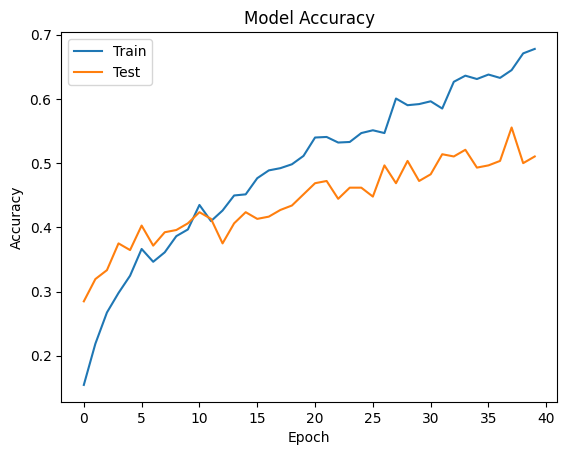

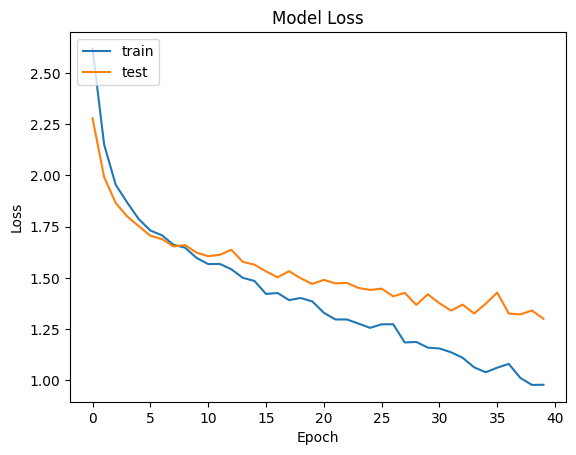

In [88]:
# PLOT MODEL HISTORY OF ACCURACY AND LOSS OVER EPOCHS
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.savefig('Initial_Model_Accuracy.png')
plt.show()
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.savefig('Initial_Model_loss.png')
plt.show()

## Post-Model Analysis

In [89]:
# PRINT LOSS AND ACCURACY PERCENTAGE ON TEST SET
print("Loss of the model is - " , model.evaluate(X_test,y_test)[0])
print("Accuracy of the model is - " , model.evaluate(X_test,y_test)[1]*100 , "%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5104 - loss: 1.3006
Loss of the model is -  1.30055570602417
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5104 - loss: 1.3006
Accuracy of the model is -  51.04166865348816 %


In [90]:
# PREDICTIONS
predictions = model.predict(X_test)
predictions=predictions.argmax(axis=1)
predictions = predictions.astype(int).flatten()
predictions = (lb.inverse_transform((predictions)))
predictions = pd.DataFrame({'Predicted Values': predictions})

# ACTUAL LABELS
actual=y_test.argmax(axis=1)
actual = actual.astype(int).flatten()
actual = (lb.inverse_transform((actual)))
actual = pd.DataFrame({'Actual Values': actual})

# COMBINE BOTH 
finaldf = actual.join(predictions)
finaldf[140:150]

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,Actual Values,Predicted Values
140,sad,disgust
141,surprise,disgust
142,neutral,sad
143,sad,sad
144,fear,fear
145,sad,sad
146,disgust,calm
147,angry,angry
148,surprise,surprise
149,angry,angry


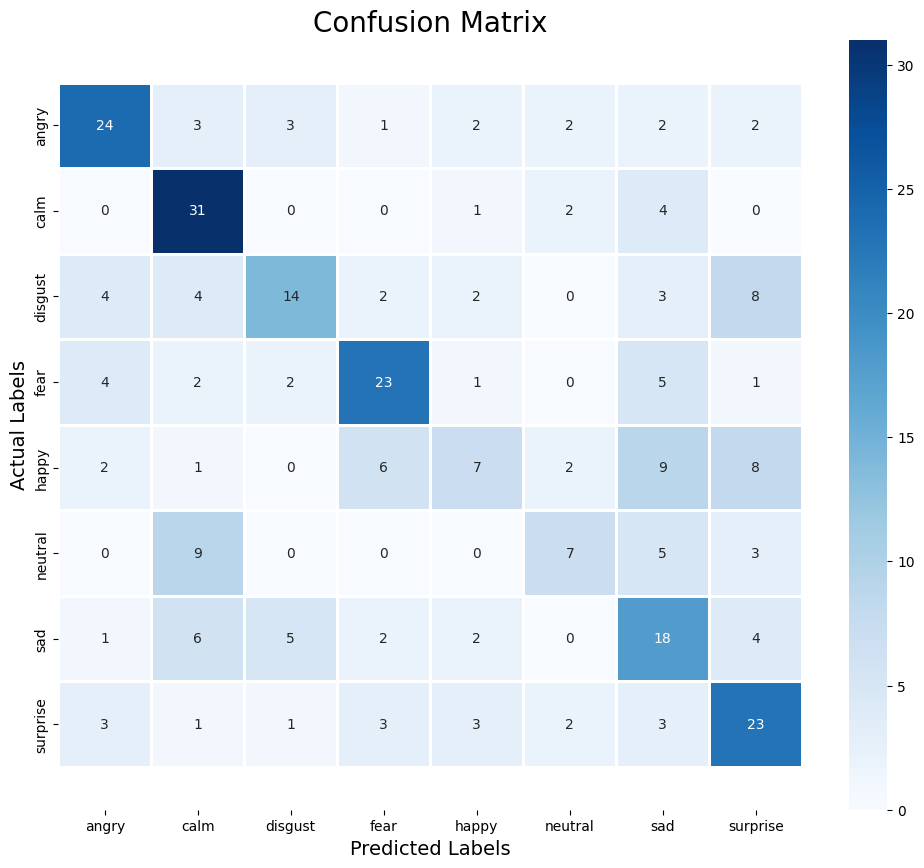

In [93]:
# CREATE CONFUSION MATRIX OF ACTUAL VS. PREDICTION 
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(actual, predictions)
plt.figure(figsize = (12, 10))
cm = pd.DataFrame(cm , index = [i for i in lb.classes_] , columns = [i for i in lb.classes_])
ax = sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='')
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.title('Confusion Matrix', size=20)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.savefig('Initial_Model_Confusion_Matrix.png')
plt.show()

In [97]:
from sklearn.metrics import classification_report
print(classification_report(actual, predictions, target_names = ['angry','calm','disgust','fear','happy','neutral','sad','surprise']))

              precision    recall  f1-score   support

       angry       0.63      0.62      0.62        39
        calm       0.54      0.82      0.65        38
     disgust       0.56      0.38      0.45        37
        fear       0.62      0.61      0.61        38
       happy       0.39      0.20      0.26        35
     neutral       0.47      0.29      0.36        24
         sad       0.37      0.47      0.41        38
    surprise       0.47      0.59      0.52        39

    accuracy                           0.51       288
   macro avg       0.51      0.50      0.49       288
weighted avg       0.51      0.51      0.50       288



## Hyperparameter Tuning

In [98]:
# TRAIN TEST SPLIT DATA
train,test = train_test_split(df_combined, test_size=0.2, random_state=0,
                               stratify=df_combined[['gender','actor']])

X_train = train.iloc[:, 3:]
y_train = train.iloc[:,:2].drop(columns=['gender'])
print(X_train.shape)

X_test = test.iloc[:,3:]
y_test = test.iloc[:,:2].drop(columns=['gender'])
print(X_test.shape)

(1152, 128)
(288, 128)


In [99]:
# NORMALIZE DATA
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
X_train = (X_train - mean)/std
X_test = (X_test - mean)/std

In [100]:
# TURN DATA INTO ARRAYS FOR KERAS
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

In [101]:
# RESHAPE TO INCLUDE 3D TENSOR
X_train = X_train[:,:,np.newaxis]
X_test = X_test[:,:,np.newaxis]

In [104]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()

# ✅ Fit ONLY on training labels
lb.fit(y_train)

# ✅ Transform using same mapping
y_train = to_categorical(lb.transform(y_train))
y_test  = to_categorical(lb.transform(y_test))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [117]:
from tensorflow.keras import layers, Sequential
from tensorflow.keras.regularizers import l2
from tensorflow import keras

def make_classifier(optimizer='adam'):   # ✅ THIS LINE IS CRITICAL
    
    from tensorflow.keras import layers, Sequential
    from tensorflow.keras.regularizers import l2

    model = Sequential()
    
    model.add(layers.Conv1D(64, kernel_size=3, activation='relu',
                            padding='same',
                            input_shape=(X_train.shape[1], 1)))
    
    model.add(layers.Conv1D(128, kernel_size=3, activation='relu',
                            padding='same',
                            kernel_regularizer=l2(0.01)))
    
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Dropout(0.4))
    
    model.add(layers.Conv1D(128, kernel_size=3, activation='relu',
                            padding='same'))
    
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Dropout(0.4))
    
    model.add(layers.Flatten())
    
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.4))
    
    model.add(layers.Dense(8, activation='softmax'))
    
    # ✅ USE optimizer passed from GridSearch
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )
    
    return model

In [118]:
y_trainHot=np.argmax(y_train, axis=1)

In [121]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
lb.fit(y_train)

y_train_int = lb.transform(y_train)

classifier = KerasClassifier(
    model=make_classifier,
    verbose=0
)

params = {
    'batch_size': [32],
    'epochs': [10, 20],
    'model__optimizer': ['adam', 'sgd']
}

grid_search = GridSearchCV(
    estimator=classifier,
    param_grid=params,
    scoring='accuracy',
    cv=3,
    error_score='raise'   # 🔥 shows real error
)

grid_result = grid_search.fit(X_train, y_train_int)

ValueError: y should be a 1d array, got an array of shape (1152, 8) instead.

In [ ]:
grid_search.best_params_

In [ ]:
grid_search.best_score_